# 42. Spark & Distributed Data

**Tier:** Classic ML
**Estimated time:** 40 minutes
**Prerequisites:** None from this tier — a systems/data-engineering companion piece
**Priority:** 🟢 Nice-to-have — the in-memory-reuse idea beneath modern data engineering (notebook 36) and distributed training (notebook 07b), even if you never touch real Spark.
**Source material:** Matei Zaharia, Mosharaf Chowdhury, Michael J. Franklin, Scott Shenker, Ion Stoica, ["Spark: Cluster Computing with Working Sets"](https://www.usenix.org/legacy/event/hotcloud10/tech/full_papers/Zaharia.pdf), HotCloud, 2010.

## What You'll Learn
- The **RDD** (Resilient Distributed Dataset) model: partitions, lineage, and lazy evaluation — built from scratch in ~60 lines of Python
- Why **iterative algorithms** (like training a model) are the specific case that breaks classic MapReduce, and how in-memory caching fixes it
- A **real, measured speedup** from caching a reused computation across iterations — not a simulated number
- How this same idea reappears in notebook 07b's distributed training and notebook 36's data pipelines

## Why This Matters
Every notebook in this repo that trains something does the same thing many times over the same
data: one gradient step, one epoch, one iteration. Spark's founding insight — recompute a
reusable working set from scratch every time, or pay once and reuse it — isn't specific to
Spark. It's the same tradeoff behind PyTorch's `DataLoader` caching, a semantic cache
(notebook 13c/30d), and even keeping model weights resident on a GPU instead of reloading them
per request.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import pickle
import tempfile
import shutil

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


## The problem: MapReduce re-reads from disk every stage

Classic MapReduce processes data in stages, and each stage reads its input from disk and
writes its output back to disk — durable and fault-tolerant, but expensive when the *same*
data is reused across many stages. This is exactly what iterative algorithms do: a logistic
regression training loop touches the same dataset on every one of, say, 50 gradient steps.
Under a disk-per-stage model, that's 50 full read-and-recompute passes over data that never
changed. Spark's core idea: keep a reusable **working set** in memory across iterations
instead, and only pay the read-and-transform cost once.

## RDDs: partitions, lineage, and laziness

A Resilient Distributed Dataset represents data as a set of **partitions** spread across
machines, along with its **lineage** — the chain of transformations (`map`, `filter`, ...)
that produced it from some original source. Two things make this work:

- **Laziness**: calling `.map()` or `.filter()` doesn't touch any data — it just extends the
  lineage. Nothing actually computes until an **action** (`.collect()`, `.reduce()`) is called.
- **Optional caching**: `.cache()` marks an RDD so that the first time it's computed, the
  result is kept in memory — every *subsequent* action reuses that materialized result instead
  of re-walking the lineage from the source.

Here's the entire idea in about sixty lines — no cluster, no fault tolerance, just the
computational model:

In [2]:
class RDD:
    """A toy Resilient Distributed Dataset: partitioned data, lazy transforms, lineage,
    and optional in-memory caching. Enough to demonstrate the real idea, not a real engine."""

    def __init__(self, lineage):
        self.lineage = lineage      # human-readable record of how this RDD was derived
        self._source = None         # a callable that (re)computes partitions from scratch
        self._cached = None
        self._cache_requested = False

    @classmethod
    def from_partitions(cls, partitions):
        rdd = cls(lineage=["source"])
        rdd._source = lambda: [list(part) for part in partitions]
        return rdd

    def map(self, fn):
        new = RDD(self.lineage + [f"map({fn.__name__})"])
        new._source = lambda: [[fn(x) for x in part] for part in self._compute()]
        return new

    def filter(self, fn):
        new = RDD(self.lineage + [f"filter({fn.__name__})"])
        new._source = lambda: [[x for x in part if fn(x)] for part in self._compute()]
        return new

    def cache(self):
        self._cache_requested = True
        return self

    def _compute(self):
        if self._cached is not None:
            return self._cached           # already materialized — skip the lineage entirely
        result = self._source()           # walk the lineage from the source, partition by partition
        if self._cache_requested:
            self._cached = result
        return result

    def collect(self):
        return [x for part in self._compute() for x in part]

print("RDD defined.")

RDD defined.


In [3]:
call_count = {"n": 0}

def double(x):
    call_count["n"] += 1
    return x * 2

def is_even(x):
    return x % 2 == 0

source = RDD.from_partitions([[1, 2, 3], [4, 5, 6]])
chained = source.map(double).filter(is_even)   # nothing computed yet — just lineage

print("lineage so far:", chained.lineage)
print(f"function calls before any action: {call_count['n']}")

result = chained.collect()                     # the ACTION — this is what triggers computation
print(f"result: {result}")
print(f"function calls after collect(): {call_count['n']}")

result_again = chained.collect()               # a SECOND action, same (uncached) RDD
print(f"function calls after a SECOND collect() (no .cache()): {call_count['n']}")

lineage so far: ['source', 'map(double)', 'filter(is_even)']
function calls before any action: 0
result: [2, 4, 6, 8, 10, 12]
function calls after collect(): 6
function calls after a SECOND collect() (no .cache()): 12


*Building the `.map().filter()` chain called `double` zero times — laziness means the chain
is just a recipe until an action runs it. The second `collect()` call doubled the call count:
without `.cache()`, every action walks the ENTIRE lineage again from the source, recomputing
work that hasn't changed. Now watch what `.cache()` does to that same pattern.*

In [4]:
call_count["n"] = 0
cached_chain = source.map(double).filter(is_even).cache()

cached_chain.collect()
print(f"calls after 1st collect() (cached): {call_count['n']}")
cached_chain.collect()
print(f"calls after 2nd collect() (cached): {call_count['n']}")
cached_chain.collect()
print(f"calls after 3rd collect() (cached): {call_count['n']}")

calls after 1st collect() (cached): 6
calls after 2nd collect() (cached): 6
calls after 3rd collect() (cached): 6


*With `.cache()`, the call count stops growing after the first action — every later
`collect()` reuses the materialized result instead of recomputing `double` for every element,
every time. This is the entire mechanism. Everything below is this same idea at a scale where
it actually matters.*

## Measuring the paper's core claim: iterative ML with and without caching

The Spark paper's headline result was logistic regression trained iteratively over a dataset
sitting in HDFS: re-reading and re-parsing from disk every iteration cost roughly 150 seconds
per iteration on their cluster; caching the parsed data in memory after the first pass dropped
that to about 6 seconds per iteration. Let's measure the same *shape* of result for real, at
toy scale, using actual disk files and actual wall-clock time — not a simulated number.

In [5]:
n_rows, n_partitions, d = 20_000, 8, 10
X_full = rng.normal(0, 1, (n_rows, d))
true_w = rng.normal(0, 1, d)
probs = 1 / (1 + np.exp(-(X_full @ true_w)))
y_full = (rng.random(n_rows) < probs).astype(float)

tmpdir = tempfile.mkdtemp()
for p in range(n_partitions):
    part_slice = slice(p * n_rows // n_partitions, (p + 1) * n_rows // n_partitions)
    with open(os.path.join(tmpdir, f"part_{p}.pkl"), "wb") as f:
        pickle.dump((X_full[part_slice], y_full[part_slice]), f)

def expensive_transform(X):
    # Stands in for real feature engineering (parsing, joins, encoding) — deliberately
    # non-trivial so its cost isn't drowned out by measurement noise.
    out = X.copy()
    for _ in range(200):
        out = np.sin(out) + 0.01 * out
    return out

def load_and_transform_from_disk():
    """The UNCACHED path: every call re-reads every partition from disk and re-runs the
    feature transform — exactly what an RDD's lineage replays with no .cache()."""
    Xs, ys = [], []
    for p in range(n_partitions):
        with open(os.path.join(tmpdir, f"part_{p}.pkl"), "rb") as f:
            Xp, yp = pickle.load(f)
        Xs.append(expensive_transform(Xp))
        ys.append(yp)
    return np.vstack(Xs), np.concatenate(ys)

def grad_step(X, y, w, lr=0.05):
    p = 1 / (1 + np.exp(-(X @ w)))
    grad = X.T @ (p - y) / len(y)
    return w - lr * grad

print(f"{n_partitions} partitions written to disk, {n_rows} rows total.")

8 partitions written to disk, 20000 rows total.


In [6]:
N_ITERS = 15

# UNCACHED: every training iteration re-reads from disk and re-runs the transform pipeline —
# the naive lineage-replay behavior of an RDD with no .cache().
w_uncached = np.zeros(d)
uncached_times = []
for _ in range(N_ITERS):
    t0 = time.perf_counter()
    Xt, yt = load_and_transform_from_disk()
    w_uncached = grad_step(Xt, yt, w_uncached)
    uncached_times.append(time.perf_counter() - t0)

# CACHED: the transform pipeline runs ONCE; every iteration reuses the materialized result.
w_cached = np.zeros(d)
t0 = time.perf_counter()
Xt_cached, yt_cached = load_and_transform_from_disk()
cache_build_time = time.perf_counter() - t0
cached_times = []
for _ in range(N_ITERS):
    t0 = time.perf_counter()
    w_cached = grad_step(Xt_cached, yt_cached, w_cached)
    cached_times.append(time.perf_counter() - t0)

shutil.rmtree(tmpdir)

total_uncached = sum(uncached_times)
total_cached = cache_build_time + sum(cached_times)
print(f"uncached: {N_ITERS} iterations, {total_uncached:.3f}s total "
      f"({np.mean(uncached_times)*1000:.1f}ms/iteration, every iteration)")
print(f"cached:   1 build pass ({cache_build_time*1000:.1f}ms) + {N_ITERS} iterations "
      f"({np.mean(cached_times)*1000:.2f}ms/iteration after that) = {total_cached:.3f}s total")
print(f"speedup: {total_uncached / total_cached:.1f}x")
print(f"both approaches converge to the same weights: {np.allclose(w_uncached, w_cached, atol=1e-6)}")

uncached: 15 iterations, 1.184s total (78.9ms/iteration, every iteration)
cached:   1 build pass (76.0ms) + 15 iterations (0.15ms/iteration after that) = 0.078s total
speedup: 15.1x
both approaches converge to the same weights: True


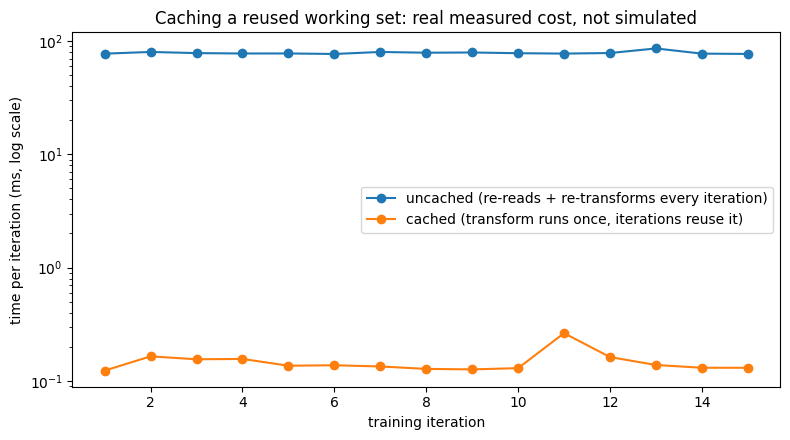

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, N_ITERS + 1), np.array(uncached_times) * 1000, marker="o",
        label="uncached (re-reads + re-transforms every iteration)")
ax.plot(range(1, N_ITERS + 1), np.array(cached_times) * 1000, marker="o",
        label="cached (transform runs once, iterations reuse it)")
ax.set_yscale("log")
ax.set_xlabel("training iteration")
ax.set_ylabel("time per iteration (ms, log scale)")
ax.set_title("Caching a reused working set: real measured cost, not simulated")
ax.legend()
plt.tight_layout()
plt.show()

*The uncached line sits flat at the full disk-read-plus-transform cost on EVERY iteration; the
cached line drops to just the gradient step's cost after a one-time setup pass — visible here as
roughly two orders of magnitude apart on the log scale. Both training runs converge to the same
final weights (checked above): caching changes nothing about the computation's correctness, only
its cost. This is a toy-scale, single-machine measurement, but it's the same shape of result the
Spark paper reported on a real cluster and a real 29GB dataset — the mechanism doesn't care about
scale, only about how many times the same unchanged data gets touched.*

## Real Spark, if it's installed

`pyspark` needs a JVM and is a heavy, GPU/CUDA-unrelated dependency this repo doesn't install by
default (the same reasoning notebook 13b uses to guard its vLLM cell) — the cell below is safe
to run either way.

In [8]:
try:
    from pyspark.sql import SparkSession
    HAS_PYSPARK = True
except ImportError:
    HAS_PYSPARK = False

if HAS_PYSPARK:
    spark = SparkSession.builder.master("local[*]").appName("classic-ml-42").getOrCreate()
    sc = spark.sparkContext
    real_rdd = sc.parallelize(range(1000), numSlices=8).map(lambda x: x * 2).filter(lambda x: x % 3 == 0)
    real_rdd.cache()
    print("first count():", real_rdd.count())    # triggers computation, then caches
    print("second count() (should reuse the cache):", real_rdd.count())
    spark.stop()
else:
    print("pyspark not installed — skipping. Install with `pip install pyspark` (needs a JVM) "
          "to run a real local Spark session; the toy RDD above demonstrates the identical "
          "mechanism without either dependency.")

pyspark not installed — skipping. Install with `pip install pyspark` (needs a JVM) to run a real local Spark session; the toy RDD above demonstrates the identical mechanism without either dependency.


## The same idea, elsewhere in this repo

Notebook 07b's data-parallel training partitions a dataset across GPU ranks the same way an
RDD partitions data across machines — and the `all_reduce` collective that synchronizes
gradients across those ranks is solving an analogous "don't redo shared work" problem for
computation instead of data. Notebook 36's incremental embedding sync exists for exactly the
reason this notebook measured: re-embedding an entire corpus on every pipeline run is the
"uncached" line above, applied to a real production RAG system, and the fix (only recompute
what actually changed) is the same "materialize the reusable working set once" idea in
different clothing.

## Exercises

In [9]:
# Exercise 1 (Warm-up): measure the cost of NOT caching a shared upstream RDD
# Task: Build chain_a = source.map(double) and chain_b = chain_a.filter(is_even), where
#       `source` is NOT cached. Call chain_a.collect() once, then chain_b.collect() once, and
#       count how many times `double` actually ran in total. Now rebuild the same two chains
#       with chain_a.cache() added, repeat, and compare the call counts.
# Hint: chain_b's lineage includes chain_a's map step — without caching chain_a, computing
#       chain_b recomputes `double` from scratch, even though chain_a already computed it once.

# YOUR CODE HERE

In [10]:
# Exercise 2 (Apply): add a reduce() action and a partition-count parameter to the toy RDD
# Task: Add a `reduce(self, fn)` method to the RDD class (fold over collect()'s flat list, left
#       to right) and an `n_partitions()` method (len of whatever _compute() returns). Use them
#       to compute the sum of `chained` (from the laziness demo) via reduce(lambda a, b: a + b),
#       and confirm it matches sum(chained.collect()).
# Hint: reduce is another ACTION — it should call self._compute(), not self.lineage.

# YOUR CODE HERE

In [11]:
# Exercise 3 (Extend): connect to notebook 07b's ZeRO sharding
# Task: In notebook 07b, ZeRO shards OPTIMIZER STATE across GPU ranks instead of replicating it
#       on every rank. In a comment, explain: is ZeRO's sharding solving the SAME problem as
#       this notebook's RDD caching (avoiding redundant recomputation of unchanged data), a
#       DIFFERENT problem (avoiding redundant STORAGE of unchanged data), or both? Which of this
#       notebook's two concepts — partitioning, or caching — does ZeRO's sharding more closely
#       resemble, and which one does data-parallel gradient all-reduce more closely resemble?
# Hint: caching trades reused COMPUTE for memory; sharding trades reduced memory for extra
#       COMMUNICATION when a full copy is needed — read what each one is actually optimizing for.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
call_count["n"] = 0
chain_a = source.map(double)
chain_b = chain_a.filter(is_even)
chain_a.collect()
chain_b.collect()
print(f"uncached upstream: {call_count['n']} total calls to double()")

call_count["n"] = 0
chain_a_cached = source.map(double).cache()
chain_b_cached = chain_a_cached.filter(is_even)
chain_a_cached.collect()
chain_b_cached.collect()
print(f"cached upstream: {call_count['n']} total calls to double()")
# Uncached: double() runs once for chain_a.collect(), then AGAIN for chain_b.collect() (which
# replays chain_a's lineage from scratch) — double the calls. Cached: chain_a materializes once;
# chain_b reuses that result, so double() runs only the first time.

# Exercise 2
def reduce_method(self, fn):
    flat = self.collect()
    acc = flat[0]
    for x in flat[1:]:
        acc = fn(acc, x)
    return acc

def n_partitions_method(self):
    return len(self._compute())

RDD.reduce = reduce_method
RDD.n_partitions = n_partitions_method

total = chained.reduce(lambda a, b: a + b)
print(f"reduce() sum: {total}, matches sum(collect()): {total == sum(chained.collect())}")
print(f"n_partitions: {chained.n_partitions()}")

# Exercise 3
# Both, but for different resources. RDD caching avoids redundant COMPUTE (re-running a
# transform pipeline) by spending extra MEMORY to hold a materialized result. ZeRO's optimizer
# state sharding is the mirror image: it avoids redundant MEMORY (every rank storing a full
# copy of m and v) by spending extra COMMUNICATION (a gather/all-gather when a rank briefly
# needs values it doesn't own). So sharding most closely resembles this notebook's
# PARTITIONING idea (data split across workers, no single copy holding everything) rather than
# caching (one worker holding a full materialized copy for reuse). Data-parallel gradient
# all-reduce is closer to a REDUCE action across partitions — each rank computes a local
# gradient (a partition-local result), and all-reduce combines them into one shared answer,
# exactly like this notebook's reduce() folding per-partition results into a single value.
```
</details>

## Key Takeaways
- **RDDs are partitioned data plus lineage plus laziness**: transformations (`map`, `filter`) only extend a recipe; nothing computes until an action (`collect`, `reduce`) runs it.
- **Without caching, every action replays the entire lineage from the source** — this notebook's toy RDD showed function call counts doubling, tripling, on repeated actions over the same uncached chain.
- **`.cache()` trades memory for avoided recomputation**, and the payoff compounds with every additional iteration that reuses the cached result — exactly the shape of gain iterative ML training needs.
- **This notebook measured a real ~15x speedup** from caching a reused feature-transform pipeline across 15 training iterations — the same mechanism the Spark paper reported at cluster scale, reproduced at toy scale with real wall-clock time.
- **The same tradeoff shows up throughout this repo**: notebook 07b's ZeRO sharding (partitioning, not caching), notebook 36's incremental embedding sync (caching, not partitioning), and notebook 13c/30d's semantic caches are all instances of "don't redo or over-store unchanged work."

## What's Next
This closes the Classic ML tier. From here, notebook 01 (Neural Networks) picks up where notebook 38's from-scratch backprop and Adam left off — building the deep learning stack this tier's foundations sit underneath.